# HW5: Планирование пути

Сравнение `A*`, `RRT` и `RRT*` на картах Warcraft/MovingAI с визуализациями, метриками, сглаживанием и анимацией процесса поиска.


In [ ]:
from pathlib import Path
import importlib

from IPython.display import Image, Video, display

import planning_algorithms
import warcraft3_utils

planning_algorithms = importlib.reload(planning_algorithms)
warcraft3_utils = importlib.reload(warcraft3_utils)

from planning_algorithms import (
    astar_resolution_study,
    benchmark_planners,
    benchmark_query_suite,
    export_planner_animations,
    format_benchmark_table,
    plot_before_after_smoothing,
    plot_planner_comparison,
    plot_resolution_study,
    plot_single_query_dashboard,
    plot_suite_overview,
)
from warcraft3_utils import (
    plot_warcraft3_scenes,
    read_warcraft3_map,
    read_warcraft3_scene,
    read_warcraft3_scenes_from_dir,
)

def localize_rows(rows, mapping):
    localized = []
    for row in rows:
        new_row = {}
        for new_key, old_key in mapping.items():
            value = row.get(old_key)
            if isinstance(value, bool):
                value = "да" if value else "нет"
            new_row[new_key] = value
        localized.append(new_row)
    return localized


## Визуализация сцен


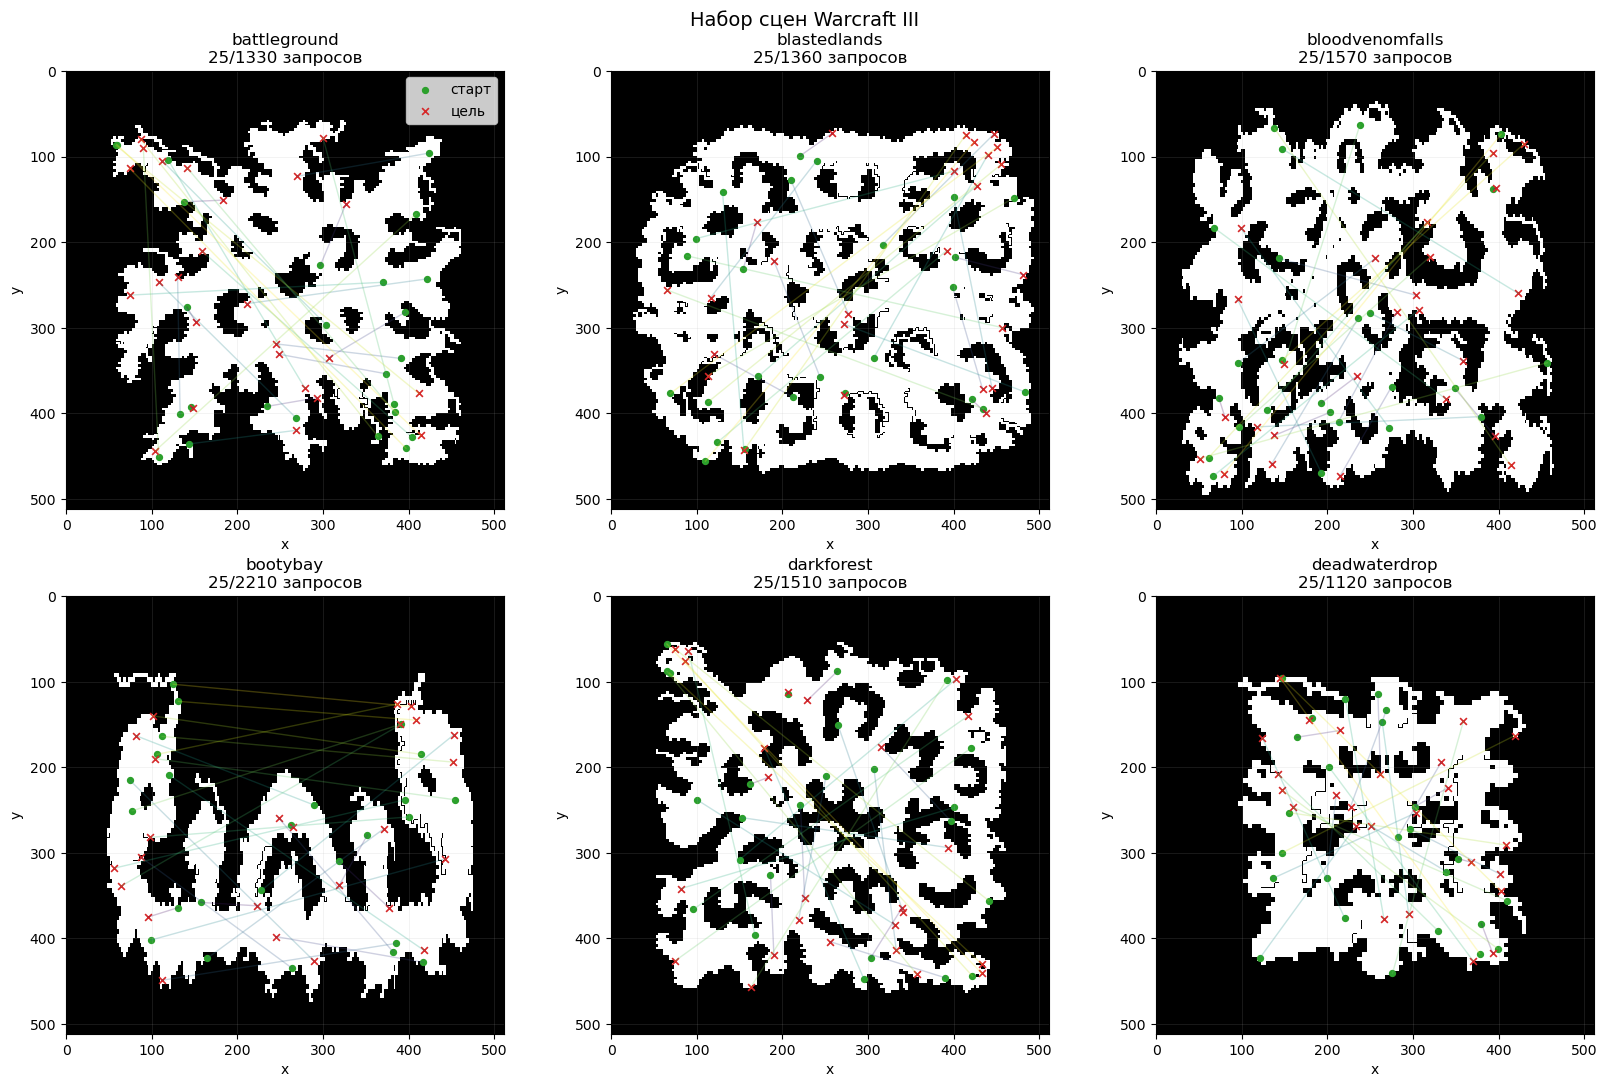

In [2]:
scene_root = Path("warcraft3")
all_scenes = read_warcraft3_scenes_from_dir(scene_root)
fig, axes = plot_warcraft3_scenes(all_scenes[:6], queries_per_scene=25, cols=3, show_map=True)


## Пример по одной сцене

В этом блоке мы сравниваем три метода планирования на одной benchmark-сцене Warcraft III, чтобы потом сопоставить качество пути и стоимость вычислений.


In [3]:
scene = read_warcraft3_scene(scene_root / "problems" / "gardenofwar.map.scen")
warcraft_map = read_warcraft3_map(scene_root / "map" / scene.map_name)
free_mask = warcraft_map.free_mask

query_index = 20
query = scene.queries[query_index]
start_xy = query.start
goal_xy = query.goal

summary_rows, results = benchmark_planners(
    free_mask,
    start_xy,
    goal_xy,
    rng_seed=7,
    benchmark_optimal_length=query.optimal_length,
)

print("Сцена:", scene.scene_name)
print("Запрос:", query_index)
print("Старт:", start_xy, "Цель:", goal_xy)
print("Оптимальная длина пути по benchmark:", round(query.optimal_length, 3))
print()

single_query_rows_ru = localize_rows(
    summary_rows,
    {
        "алгоритм": "planner",
        "успех": "success",
        "эталон": "benchmark_optimal",
        "длина": "path_length",
        "сглаженная_длина": "smoothed_length",
        "выигрыш_сглаживания_%": "smooth_gain_pct",
        "время_мс": "time_ms",
        "посещения": "visited_points",
        "коэф_обхода": "detour_ratio",
        "отклонение_от_эталона_%": "optimality_gap_pct",
    },
)

print(format_benchmark_table(
    single_query_rows_ru,
    headers=[
        "алгоритм",
        "успех",
        "эталон",
        "длина",
        "сглаженная_длина",
        "выигрыш_сглаживания_%",
        "время_мс",
        "посещения",
        "коэф_обхода",
        "отклонение_от_эталона_%",
    ],
))


Сцена: gardenofwar
Запрос: 20
Старт: (120, 455) Цель: (130, 451)
Оптимальная длина пути по benchmark: 11.657

алгоритм | успех | эталон | длина  | сглаженная_длина | выигрыш_сглаживания_% | время_мс | посещения | коэф_обхода | отклонение_от_эталона_%
---------+-------+--------+--------+------------------+-----------------------+----------+-----------+-------------+------------------------
A*       | да    | 11.657 | 11.657 | 10.77            | 7.61                  | 0.29     | 31        | 1.082       | -0.0                   
RRT      | да    | 11.657 | 21.423 | 10.77            | 49.73                 | 0.06     | 4         | 1.989       | 83.78                  
RRT*     | да    | 11.657 | 10.77  | 10.77            | 0.0                   | 739.3    | 1947      | 1.0         | -7.61                  


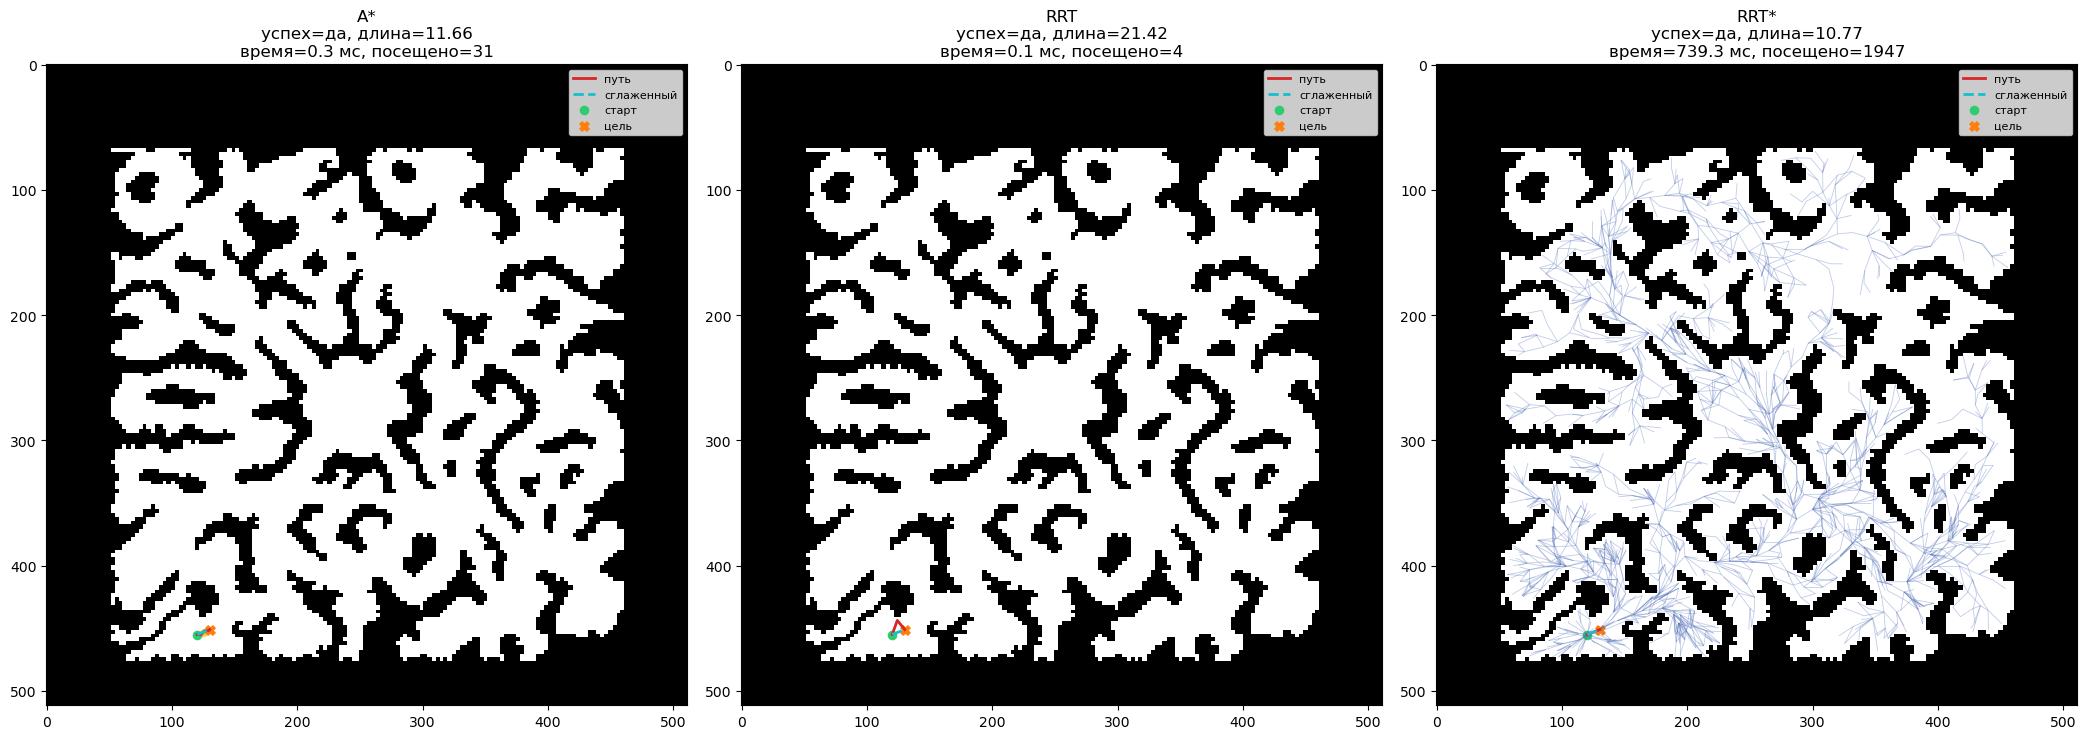

In [4]:
fig, axes = plot_planner_comparison(free_mask, start_xy, goal_xy, results)


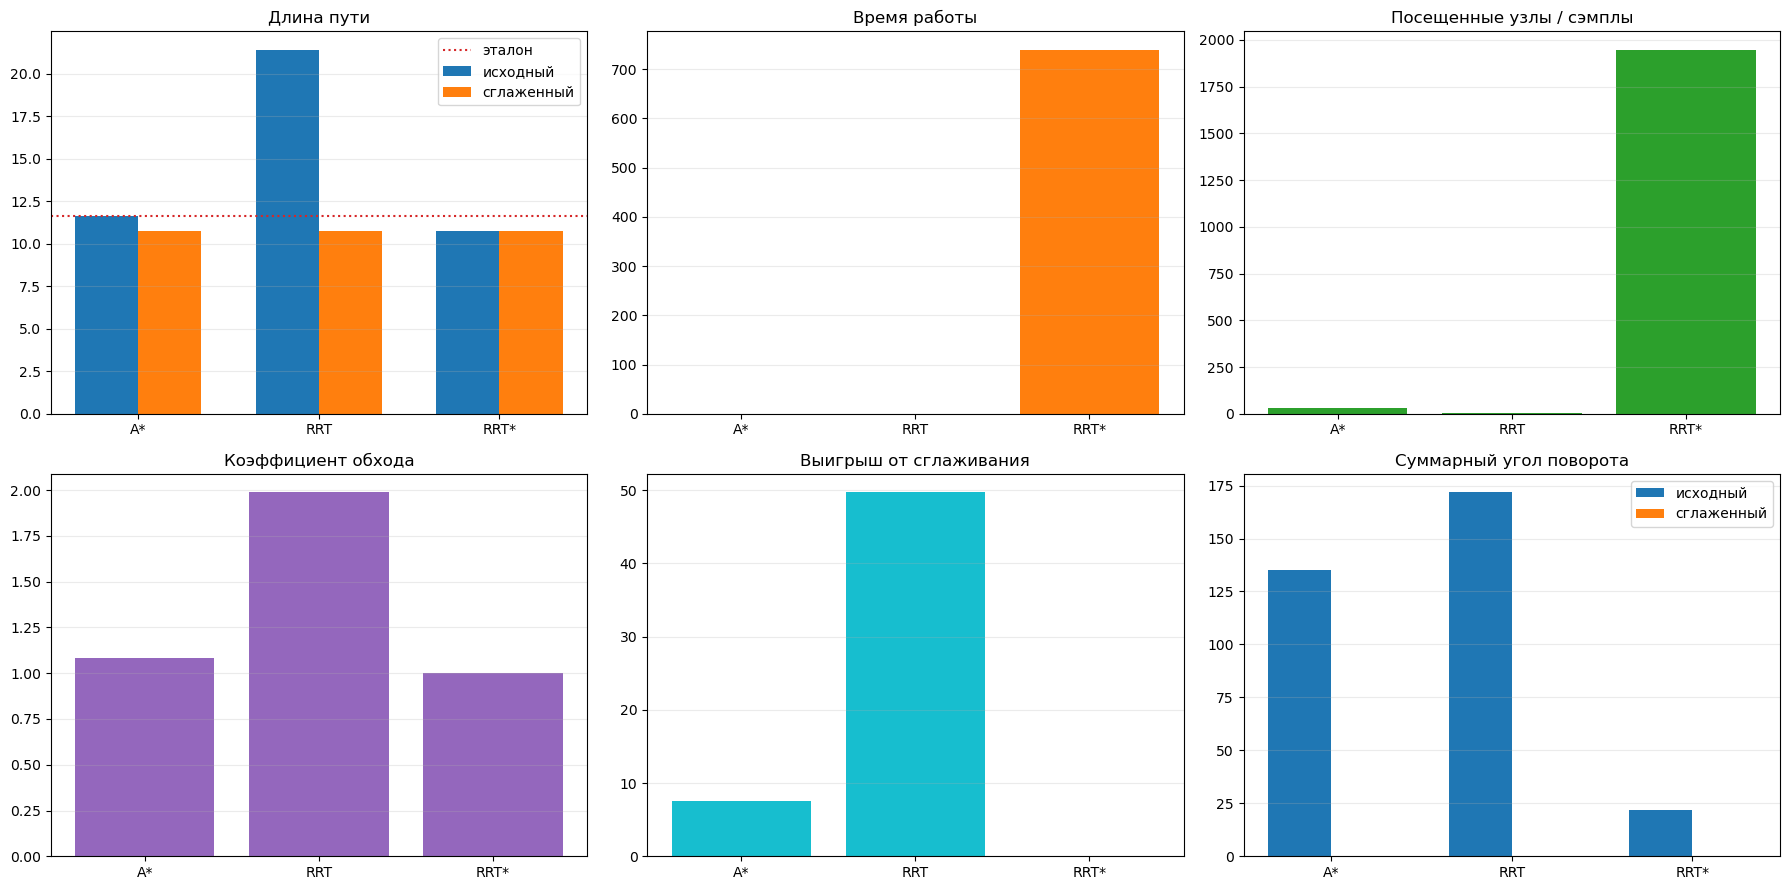

In [5]:
fig, axes = plot_single_query_dashboard(summary_rows, benchmark_optimal_length=query.optimal_length)


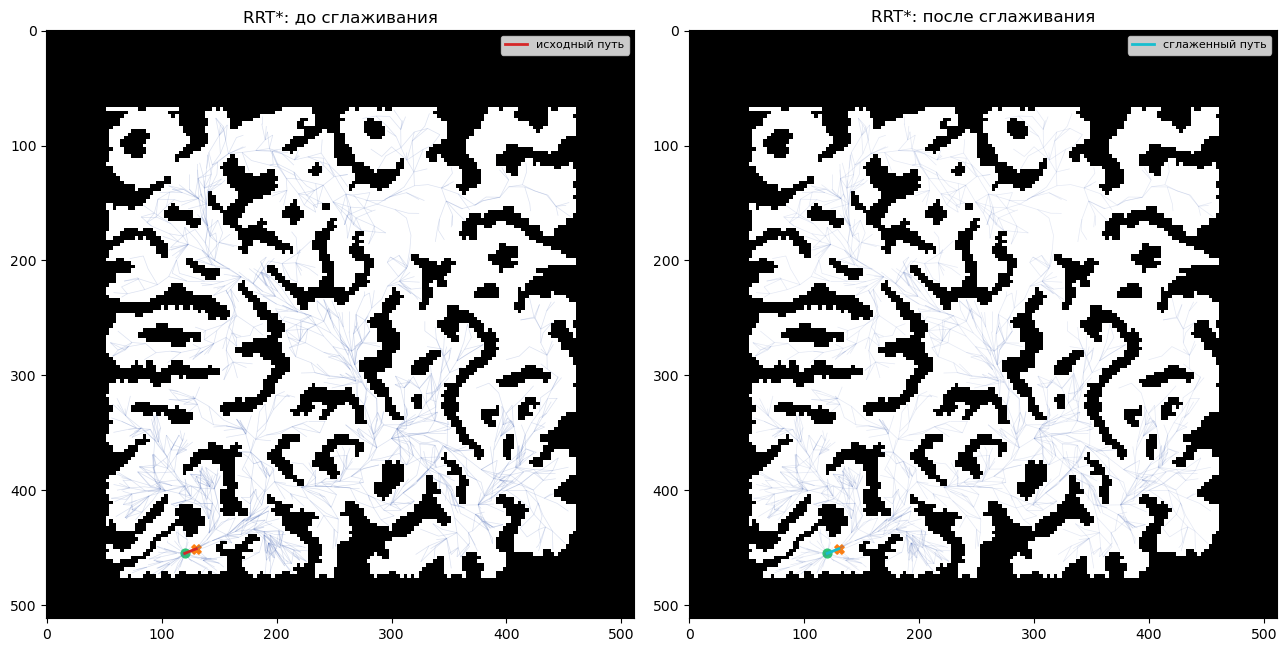

In [6]:
fig, axes = plot_before_after_smoothing(
    free_mask,
    results["RRT*"],
    start=start_xy,
    goal=goal_xy,
)


## Серия запусков по нескольким запросам

Кроме одного примера сравниваем алгоритмы на нескольких запросах и нескольких seed, чтобы оценить устойчивость, среднее время, количество посещений, качество пути и пользу сглаживания.


In [7]:
suite_query_indices = [0, 5, 10, 15, 20]
detail_rows, aggregate_rows = benchmark_query_suite(
    free_mask,
    scene.queries,
    query_indices=suite_query_indices,
    seeds=(3, 7, 11),
    planner_overrides={
        "RRT": {"max_iter": 2000, "step_size": 10.0, "goal_sample_rate": 0.14},
        "RRT*": {"max_iter": 2200, "step_size": 10.0, "neighbor_radius": 16.0},
    },
)

aggregate_rows_ru = localize_rows(
    aggregate_rows,
    {
        "алгоритм": "planner",
        "запуски": "runs",
        "успех_%": "success_rate_pct",
        "среднее_время_мс": "mean_time_ms",
        "медиана_времени_мс": "median_time_ms",
        "среднее_число_посещений": "mean_visited_points",
        "средняя_длина": "mean_path_length",
        "средняя_сглаженная_длина": "mean_smoothed_length",
        "среднее_отклонение_от_эталона_%": "mean_optimality_gap_pct",
        "средний_выигрыш_сглаживания_%": "mean_smoothing_gain_pct",
    },
)

print(format_benchmark_table(
    aggregate_rows_ru,
    headers=[
        "алгоритм",
        "запуски",
        "успех_%",
        "среднее_время_мс",
        "медиана_времени_мс",
        "среднее_число_посещений",
        "средняя_длина",
        "средняя_сглаженная_длина",
        "среднее_отклонение_от_эталона_%",
        "средний_выигрыш_сглаживания_%",
    ],
))


алгоритм | запуски | успех_% | среднее_время_мс | медиана_времени_мс | среднее_число_посещений | средняя_длина | средняя_сглаженная_длина | среднее_отклонение_от_эталона_% | средний_выигрыш_сглаживания_%
---------+---------+---------+------------------+--------------------+-------------------------+---------------+--------------------------+---------------------------------+------------------------------
A*       | 5       | 100.0   | 0.12             | 0.07               | 12                      | 6.063         | 5.74                     | 0.0                             | 4.16                         
RRT      | 15      | 100.0   | 0.05             | 0.04               | 5.8                     | 8.803         | 5.74                     | 38.03                           | 15.99                        
RRT*     | 15      | 100.0   | 415.97           | 412.18             | 1404.2                  | 5.74          | 5.74                     | -4.16                           | 0.0       

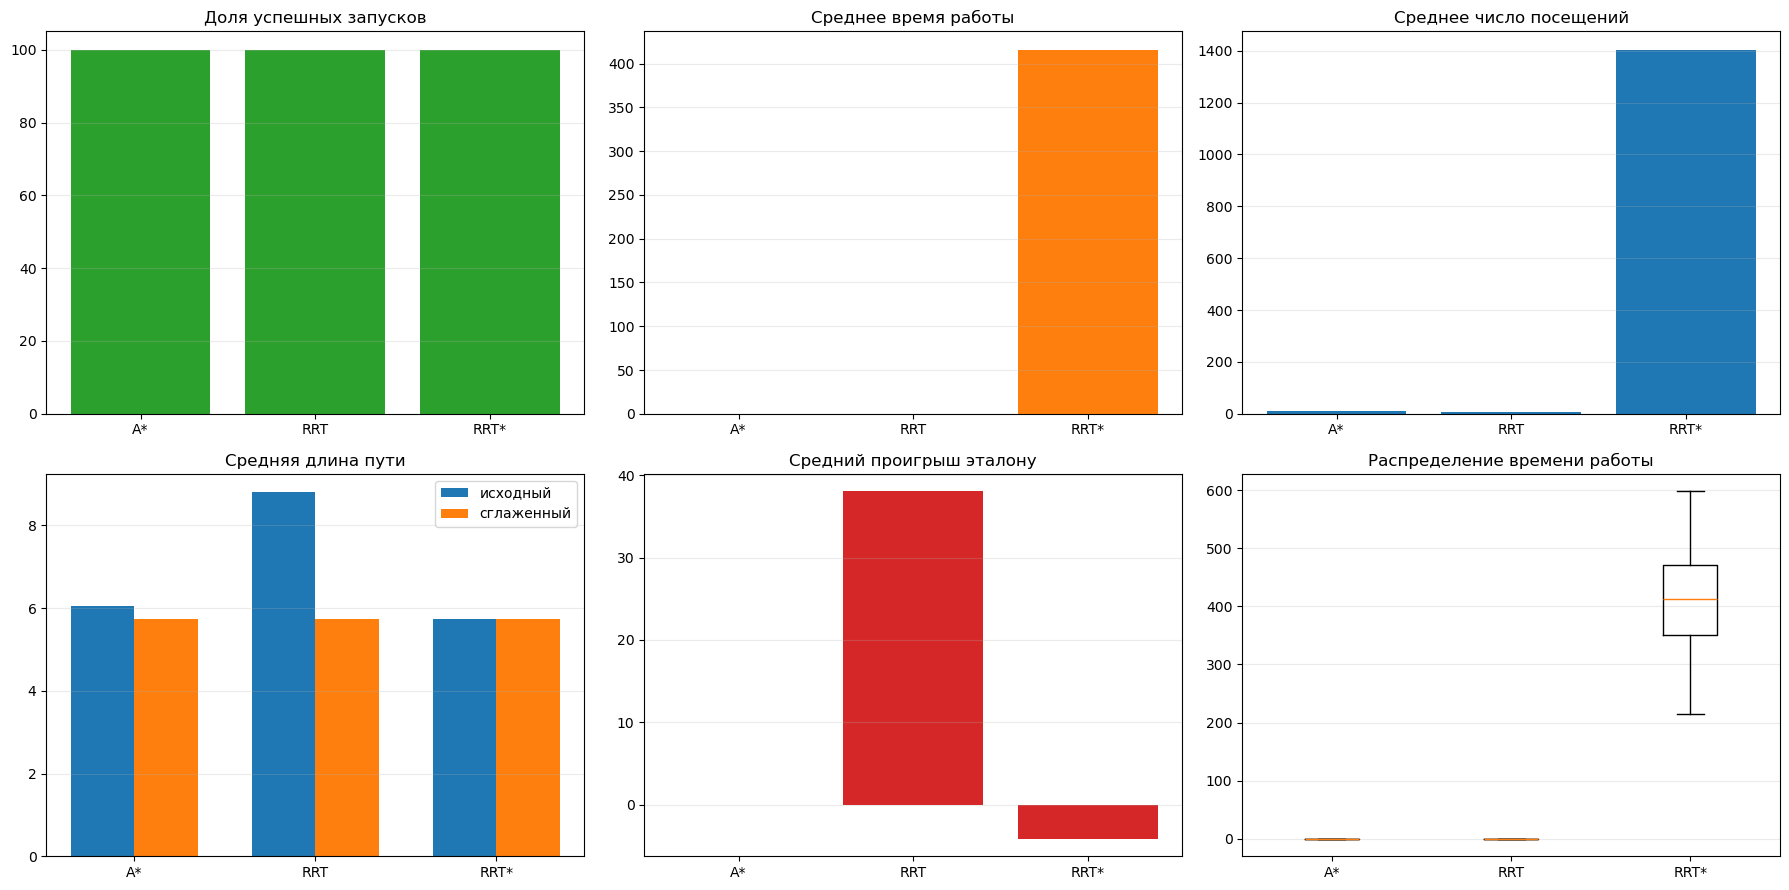

In [8]:
fig, axes = plot_suite_overview(detail_rows, aggregate_rows)


## Исследование влияния разрешения карты на A*

В этом разделе проверяется, как изменение разрешения occupancy grid влияет на время работы `A*`, число посещённых вершин и итоговую геометрию пути.


In [9]:
resolution_rows = astar_resolution_study(
    free_mask,
    start_xy,
    goal_xy,
    factors=(1, 2, 4, 8),
)

resolution_rows_ru = [
    {
        "алгоритм": f"A* x{row['factor']}",
        "успех": row["success"],
        "длина": row["path_length"],
        "сглаженная_длина": None,
        "время_мс": row["time_ms"],
        "посещения": row["visited_points"],
    }
    for row in resolution_rows
]

print(format_benchmark_table(
    resolution_rows_ru,
    headers=["алгоритм", "успех", "длина", "сглаженная_длина", "время_мс", "посещения"],
))


алгоритм | успех | длина  | сглаженная_длина | время_мс | посещения
---------+-------+--------+------------------+----------+----------
A* x1    | True  | 11.657 | None             | 0.28     | 31       
A* x2    | True  | 11.657 | None             | 0.1      | 12       
A* x4    | True  | 9.657  | None             | 0.03     | 4        
A* x8    | True  | 8.0    | None             | 0.01     | 2        


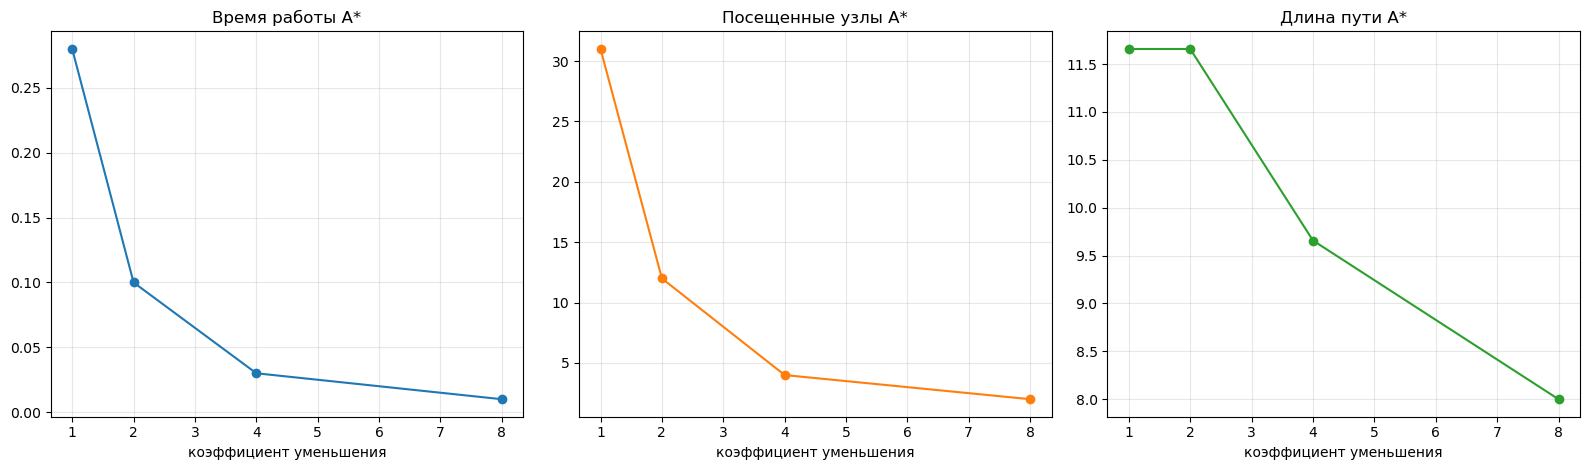

In [10]:
fig, axes = plot_resolution_study(resolution_rows)


## Экспорт анимации поиска

Эта ячейка заново собирает анимации поиска для `A*`, `RRT` и `RRT*` и сохраняет их в `artifacts/` в формате `mp4`, а если `ffmpeg` недоступен, автоматически переключается на `gif`.


In [11]:
artifacts_dir = Path("artifacts")
saved_animations = export_planner_animations(
    free_mask,
    results,
    start=start_xy,
    goal=goal_xy,
    output_dir=artifacts_dir,
    max_frames=160,
    fps=15,
    dpi=120,
)

for planner_name, saved_animation in saved_animations.items():
    print(f"{planner_name}: {saved_animation}")
    if saved_animation.suffix.lower() == ".gif":
        display(Image(filename=str(saved_animation)))
    else:
        display(Video(str(saved_animation), embed=True))


A*: artifacts\astar_search.mp4


RRT: artifacts\rrt_search.mp4


RRT*: artifacts\rrt_star_search.mp4


## Выводы

- `A*` остаётся хорошим эталоном для дискретной карты и даёт почти идеальную длину пути по benchmark-оценке там, где есть корректная occupancy grid.
- `RRT` обычно быстрее находит допустимый путь, но его качество сильнее зависит от случайных сэмплов, параметров и числа итераций.
- `RRT*` работает заметно медленнее из-за перестройки дерева, зато чаще даёт путь лучше базового `RRT` и ближе к эталону.
- Сглаживание полезно и после `A*`, и особенно после `RRT`, потому что уменьшает длину пути и убирает резкие изломы.
- При увеличении разрешения карты `A*` вынужден исследовать больше состояний, поэтому растут время работы и число посещённых узлов.
- Узкие коридоры особенно сложны для sampling-based алгоритмов, потому что им тяжелее случайно попадать в проход и чаще приходится долго искать удачную последовательность сэмплов.
